In [1]:
!pip install pandas numpy scipy networkx python-louvain gseapy statsmodels scikit-learn seaborn matplotlib


In [2]:
import psutil
print(psutil.virtual_memory())


svmem(total=33659150336, available=32497422336, percent=3.5, used=717172736, free=31233310720, active=1215655936, inactive=844673024, buffers=120938496, cached=1587728384, shared=4399104)


In [4]:
import os, glob

DATA_DIR = "../data" 

print("Current working dir:", os.getcwd())
print("Files in DATA_DIR:", len(os.listdir(DATA_DIR)))
print(sorted(os.listdir(DATA_DIR))[:10])

# quick search
print(glob.glob(DATA_DIR + "/*phospho*Tumor*.csv")[:2])
print(glob.glob(DATA_DIR + "/*phospho*Normal*.csv")[:2])


Current working dir: /mnt/batch/tasks/shared/LS_root/mounts/clusters/barmoudeleyla1/code/HCC_project/notebooks
Files in DATA_DIR: 5
['.amlignore', '.amlignore.amltmp', '.ipynb_checkpoints', 'clean_phosphosite_normal.csv', 'clean_phosphosite_tumor.csv']
[]
[]


In [5]:
import pandas as pd

PH_T = DATA_DIR + "/clean_phosphosite_tumor.csv"
PH_N = DATA_DIR + "/clean_phosphosite_normal.csv"

# tumor = comma
ph_t = pd.read_csv(PH_T, sep=",")

# normal = semicolon
ph_n = pd.read_csv(PH_N, sep=";")

print("Tumor cols:", ph_t.columns[:8].tolist())
print("Normal cols:", ph_n.columns[:8].tolist())




Tumor cols: ['gene', 'protein', 'site', 'peptide', 'charge', '112', '113', '123']
Normal cols: ['gene', 'protein', 'site', 'peptide', 'charge', '111', '114', '124']


In [6]:
import re
import numpy as np

def get_sample_cols(df):
    return [c for c in df.columns if re.fullmatch(r"\d+", str(c))]

def add_phosphosite_id(df):
    if "phosphosite_id" not in df.columns:
        df["phosphosite_id"] = df["protein"].astype(str) + "_" + df["site"].astype(str)
    return df

ph_t = add_phosphosite_id(ph_t)
ph_n = add_phosphosite_id(ph_n)

tumor_samples  = get_sample_cols(ph_t)
normal_samples = get_sample_cols(ph_n)

Xt = ph_t[tumor_samples].apply(pd.to_numeric, errors="coerce")
Xn = ph_n[normal_samples].apply(pd.to_numeric, errors="coerce")

Xt.index = ph_t["phosphosite_id"].astype(str)
Xn.index = ph_n["phosphosite_id"].astype(str)

# collapse duplicates (multiple peptides per site)
Xt = Xt.groupby(Xt.index).median()
Xn = Xn.groupby(Xn.index).median()

print("Xt:", Xt.shape, "Xn:", Xn.shape)



Xt: (57850, 165) Xn: (57850, 165)


In [7]:
def filter_by_missing(X, max_missing=0.5):
    miss = X.isna().mean(axis=1)
    return X.loc[miss <= max_missing].copy()

Xt_f = filter_by_missing(Xt, max_missing=0.5)
Xn_f = filter_by_missing(Xn, max_missing=0.5)

common_sites = Xt_f.index.intersection(Xn_f.index)
Xt_f = Xt_f.loc[common_sites]
Xn_f = Xn_f.loc[common_sites]

print("After filtering common:", Xt_f.shape, Xn_f.shape)


After filtering common: (18704, 165) (18704, 165)


In [8]:
def left_censored_impute(X, width=0.3, downshift=1.8, random_state=0):
    rng = np.random.default_rng(random_state)
    X = X.copy()
    for col in X.columns:
        vals = X[col].dropna()
        if len(vals) < 10:
            continue
        mu = vals.mean()
        sigma = vals.std()
        if sigma == 0 or np.isnan(sigma):
            continue
        imp_mean = mu - downshift * sigma
        imp_std  = sigma * width
        mask = X[col].isna()
        n = mask.sum()
        if n > 0:
            X.loc[mask, col] = rng.normal(imp_mean, imp_std, n)
    return X

Xt_imp = left_censored_impute(Xt_f, random_state=0)
Xn_imp = left_censored_impute(Xn_f, random_state=0)

print("Any NaNs left?", Xt_imp.isna().any().any(), Xn_imp.isna().any().any())


Any NaNs left? False False


In [9]:
from scipy.optimize import linear_sum_assignment

def hungarian_pair_samples(Xt, Xn, use_rank=True, fillna_value=0.0):
    common_sites = Xt.index.intersection(Xn.index)
    Xt2 = Xt.loc[common_sites].copy()
    Xn2 = Xn.loc[common_sites].copy()

    if use_rank:
        Xt2 = Xt2.rank(axis=0, method="average")
        Xn2 = Xn2.rank(axis=0, method="average")

    A = Xt2.T.fillna(fillna_value).to_numpy(dtype=float)
    B = Xn2.T.fillna(fillna_value).to_numpy(dtype=float)

    C = np.corrcoef(A, B)
    CtN = pd.DataFrame(
        C[:A.shape[0], A.shape[0]:],
        index=Xt2.columns.astype(str),
        columns=Xn2.columns.astype(str)
    )

    cost = -CtN.to_numpy()
    row_ind, col_ind = linear_sum_assignment(cost)

    pairs = pd.DataFrame({
        "tumor_sample": CtN.index[row_ind],
        "normal_sample": CtN.columns[col_ind],
        "corr": CtN.to_numpy()[row_ind, col_ind]
    }).sort_values("corr", ascending=False).reset_index(drop=True)

    Xt_pair = Xt.loc[:, pairs["tumor_sample"]].copy()
    Xn_pair = Xn.loc[:, pairs["normal_sample"]].copy()

    patient_ids = [f"P{i+1}" for i in range(len(pairs))]
    Xt_pair.columns = patient_ids
    Xn_pair.columns = patient_ids

    return Xt_pair, Xn_pair, pairs

Xt_pair, Xn_pair, pairs = hungarian_pair_samples(Xt_imp, Xn_imp)

print(pairs["corr"].describe())
print("Xt_pair:", Xt_pair.shape, "Xn_pair:", Xn_pair.shape)


count    165.000000
mean       0.884088
std        0.098398
min        0.467603
25%        0.905033
50%        0.921858
75%        0.929256
max        0.953525
Name: corr, dtype: float64
Xt_pair: (18704, 165) Xn_pair: (18704, 165)


In [10]:
Xdiff = Xt_pair - Xn_pair
print("Xdiff:", Xdiff.shape)


Xdiff: (18704, 165)


In [12]:
######### none
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

rows = []

for s in Xdiff.index:
    d = Xdiff.loc[s].dropna()
    if len(d) > 30:
        stat, p = wilcoxon(d)
        rows.append((s, d.mean(), p))

diff_res = pd.DataFrame(rows, columns=["site","mean_delta","p"])
diff_res["fdr"] = multipletests(diff_res["p"], method="fdr_bh")[1]

sig = diff_res.query("fdr < 0.05")

print("Significant tumor-specific sites:", len(sig))
sig.head()


Significant tumor-specific sites: 14777


,site,mean_delta,p,fdr
0,ENSP00000000412.3_S267,-0.356583,2.919815e-13,1.047616e-12
2,ENSP00000001008.4_S453,0.170409,2.852890e-03,4.076429e-03
5,ENSP00000003302.4_S1053,0.368105,1.843108e-09,4.648528e-09
6,ENSP00000003302.4_S375,-0.540171,1.322897e-07,2.834953e-07
7,ENSP00000003302.4_S521,-0.273874,8.622524e-06,1.569899e-05


In [122]:
sig

,phosphosite_id,module,mean_delta,p,n,fdr
0,ENSP00000004982.3_S16,0,-1.125002,2.181684e-25,165,4.286368e-24
1,ENSP00000280772.1_S1459,0,-1.785853,6.317931e-27,165,2.098944e-25
2,ENSP00000316029.9_S883,0,-0.583400,7.558837e-15,165,3.138999e-14
3,ENSP00000319141.4_S260,0,-0.775230,5.147591e-17,165,2.680416e-16
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19
...,...,...,...,...,...,...
2059,ENSP00000497767.1_T39,1,-1.586650,1.160931e-28,165,2.085993e-26
2060,ENSP00000498441.1_S453,381,-0.626745,1.842919e-10,165,5.089320e-10
2061,ENSP00000498441.1_S586,381,-0.463904,3.604595e-06,165,6.790246e-06
2062,ENSP00000499465.1_S168,11,-0.755579,1.390743e-15,165,6.208223e-15


In [ ]:
sig.to.save()

In [11]:
from pathlib import Path
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# --- Config ---
CACHE_DIR = Path("cache_stats")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Optional: add your own dataset/version tag if Xdiff changes across runs
RESULTS_PATH = CACHE_DIR / "wilcoxon_fdr_minN30.pkl"
THR_FDR = 0.05
MIN_N = 30

# --- Load cached results if present ---
if RESULTS_PATH.exists():
    diff_res = pd.read_pickle(RESULTS_PATH)
else:
    rows = []
    # .index assumed to be "site" ids
    for s in Xdiff.index:
        d = Xdiff.loc[s].dropna()

        # Ensure numeric + finite (extra safety)
        d = pd.to_numeric(d, errors="coerce")
        d = d[np.isfinite(d)]

        if len(d) > MIN_N:
            # Wilcoxon can fail if all differences are zero etc.
            try:
                stat, p = wilcoxon(d)
            except ValueError:
                continue

            rows.append((s, float(np.mean(d)), float(p), int(len(d))))

    diff_res = pd.DataFrame(rows, columns=["site", "mean_delta", "p", "n"])
    if len(diff_res):
        diff_res["fdr"] = multipletests(diff_res["p"], method="fdr_bh")[1]
    else:
        diff_res["fdr"] = []

    diff_res.to_pickle(RESULTS_PATH)

# --- Use results (fast after restart) ---
sig = diff_res.query("fdr < @THR_FDR").sort_values("fdr")
print("Significant tumor-specific sites:", len(sig))
sig.head()


Significant tumor-specific sites: 14777


,site,mean_delta,p,n,fdr
15060,ENSP00000384537.2_S1331,-1.730186,1.670306e-28,165,2.085993e-26
9972,ENSP00000350990.3_S920,-1.373677,1.271588e-28,165,2.085993e-26
486,ENSP00000216392.7_S639,-2.914998,7.914547e-29,165,2.085993e-26
489,ENSP00000216392.7_Y76,-2.058482,1.581709e-28,165,2.085993e-26
9940,ENSP00000350990.3_S1666,-1.501615,8.831097e-29,165,2.085993e-26


In [13]:
def corr_to_edges(corr, thr=0.6):
    edges = (
        corr.where(np.abs(corr) >= thr)
            .stack()
            .rename_axis(("site1","site2"))
            .reset_index(name="rho")
    )
    return edges[edges["site1"] < edges["site2"]]


In [ ]:
############# none
import networkx as nx

corr_d = Xdiff.T.corr(method="spearman")

edges_d = corr_to_edges(corr_d, thr=0.6)

Gd = nx.from_pandas_edgelist(edges_d, "site1","site2", edge_attr="rho")

print("Nodes:", Gd.number_of_nodes())
print("Edges:", Gd.number_of_edges())


In [14]:
from pathlib import Path
import networkx as nx
import pandas as pd
import pickle

CACHE_DIR = Path("cache_corr_graph")
CACHE_DIR.mkdir(exist_ok=True)

THR = 0.6

CORR_PATH  = CACHE_DIR / "corr.pkl"
EDGES_PATH = CACHE_DIR / "edges.pkl"
GRAPH_PATH = CACHE_DIR / "graph.pkl"


# 1) correlation
if CORR_PATH.exists():
    corr_d = pd.read_pickle(CORR_PATH)
else:
    corr_d = Xdiff.T.corr(method="spearman")
    corr_d.to_pickle(CORR_PATH)


# 2) edges
if EDGES_PATH.exists():
    edges_d = pd.read_pickle(EDGES_PATH)
else:
    edges_d = corr_to_edges(corr_d, thr=THR)
    edges_d.to_pickle(EDGES_PATH)


# 3) graph
if GRAPH_PATH.exists():
    with open(GRAPH_PATH, "rb") as f:
        Gd = pickle.load(f)
else:
    Gd = nx.from_pandas_edgelist(edges_d, "site1", "site2", edge_attr="rho")
    with open(GRAPH_PATH, "wb") as f:
        pickle.dump(Gd, f)


In [129]:
import os
import matplotlib.pyplot as plt

RESULTS_DIR = "HCC_project/results"
edges_d.to_csv(f"{RESULTS_DIR}/differential_network_edges.csv", index=False)


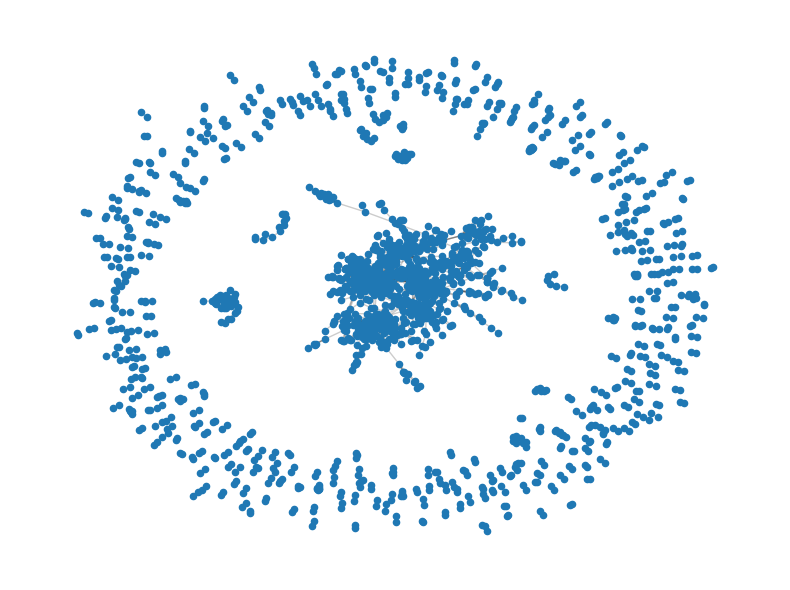

In [130]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
pos = nx.spring_layout(Gd, seed=42)

nx.draw_networkx_nodes(Gd, pos, node_size=20)
nx.draw_networkx_edges(Gd, pos, alpha=0.2)

plt.axis("off")
plt.tight_layout()

plt.savefig(f"{RESULTS_DIR}/Figure3_network.pdf")
plt.show()


In [131]:
corr_d.to_csv(f"{RESULTS_DIR}/differential_correlation_matrix.csv")


KeyboardInterrupt: 

In [15]:
import community.community_louvain as community_louvain

partition = community_louvain.best_partition(Gd)

modules = pd.Series(partition, name="module")
modules.head()


ENSP00000004982.3_S16      0
ENSP00000280772.1_S1459    0
ENSP00000316029.9_S883     0
ENSP00000319141.4_S260     0
ENSP00000333938.7_S80      0
Name: module, dtype: int64

In [16]:
import community.community_louvain as community_louvain

partition = community_louvain.best_partition(Gd)

modules = pd.Series(partition, name="module")
modules.head()


ENSP00000004982.3_S16      0
ENSP00000280772.1_S1459    0
ENSP00000316029.9_S883     0
ENSP00000319141.4_S260     0
ENSP00000333938.7_S80      0
Name: module, dtype: int64

In [17]:
print(corr_d.shape)


(18704, 18704)


In [18]:
modules.nunique()


382

In [19]:
modules.value_counts().head(10)


1     194
21    170
5     145
0     121
10    116
2      91
34     68
15     61
17     50
24     39
Name: module, dtype: int64

In [20]:
modules.value_counts().describe()


count    382.000000
mean       5.403141
std       18.418717
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max      194.000000
Name: module, dtype: float64

In [21]:
modules_df = modules.rename_axis("phosphosite_id").reset_index()
modules_df.head()



,phosphosite_id,module
0,ENSP00000004982.3_S16,0
1,ENSP00000280772.1_S1459,0
2,ENSP00000316029.9_S883,0
3,ENSP00000319141.4_S260,0
4,ENSP00000333938.7_S80,0


In [22]:
diff_res = diff_res.rename(columns={"site":"phosphosite_id"})

summary = modules_df.merge(diff_res, on="phosphosite_id", how="left")
summary.head()


,phosphosite_id,module,mean_delta,p,n,fdr
0,ENSP00000004982.3_S16,0,-1.125002,2.181684e-25,165,4.286368e-24
1,ENSP00000280772.1_S1459,0,-1.785853,6.317931e-27,165,2.098944e-25
2,ENSP00000316029.9_S883,0,-0.583400,7.558837e-15,165,3.138999e-14
3,ENSP00000319141.4_S260,0,-0.775230,5.147591e-17,165,2.680416e-16
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19


In [24]:
sig = summary.query("fdr < 0.05")


In [25]:
known_annotated = set()
known_kinase_sites = set()


In [26]:
dark = summary.copy()
print(dark.shape)


(2064, 6)


In [27]:
# modules
modules_df = modules.rename_axis("phosphosite_id").reset_index()

# differential stats
diff_df = diff_res.rename(columns={"site":"phosphosite_id"})

# merge
summary = modules_df.merge(diff_df, on="phosphosite_id", how="left")

print(summary.shape)
summary.head()


(2064, 6)


,phosphosite_id,module,mean_delta,p,n,fdr
0,ENSP00000004982.3_S16,0,-1.125002,2.181684e-25,165,4.286368e-24
1,ENSP00000280772.1_S1459,0,-1.785853,6.317931e-27,165,2.098944e-25
2,ENSP00000316029.9_S883,0,-0.583400,7.558837e-15,165,3.138999e-14
3,ENSP00000319141.4_S260,0,-0.775230,5.147591e-17,165,2.680416e-16
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19


In [132]:
summary.to.save("HCC_project/results/summary.csv")

AttributeError: 'DataFrame' object has no attribute 'to'

In [28]:
sig = summary.query("fdr < 0.05")
print("Tumor-specific sites:", len(sig))


Tumor-specific sites: 1830


In [29]:
sig1 = summary.query("fdr < 0.05 and abs(mean_delta) > 0.5")
sig1

,phosphosite_id,module,mean_delta,p,n,fdr
0,ENSP00000004982.3_S16,0,-1.125002,2.181684e-25,165,4.286368e-24
1,ENSP00000280772.1_S1459,0,-1.785853,6.317931e-27,165,2.098944e-25
2,ENSP00000316029.9_S883,0,-0.583400,7.558837e-15,165,3.138999e-14
3,ENSP00000319141.4_S260,0,-0.775230,5.147591e-17,165,2.680416e-16
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19
...,...,...,...,...,...,...
2058,ENSP00000497767.1_S36,1,-2.263852,7.914547e-29,165,2.085993e-26
2059,ENSP00000497767.1_T39,1,-1.586650,1.160931e-28,165,2.085993e-26
2060,ENSP00000498441.1_S453,381,-0.626745,1.842919e-10,165,5.089320e-10
2062,ENSP00000499465.1_S168,11,-0.755579,1.390743e-15,165,6.208223e-15


In [30]:
dark = sig.copy()


In [31]:
import networkx as nx

degree = dict(Gd.degree())

summary["degree"] = summary["phosphosite_id"].map(degree).fillna(0)


In [32]:
summary["score"] = (
    -np.log10(summary["fdr"] + 1e-12) *
    abs(summary["mean_delta"]) *
    (summary["degree"] + 1)
)

top_sites = summary.sort_values("score", ascending=False)
top_sites.head(20)


,phosphosite_id,module,mean_delta,p,n,fdr,degree,score
267,ENSP00000319281.3_T36,10,-1.583641,4.462679e-25,165,8.151361e-24,49,950.184562
10,ENSP00000468156.1_S382,1,1.721878,8.209061e-29,165,2.085993e-26,43,909.151474
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19,57,838.476119
63,ENSP00000263980.3_S693,10,-0.799856,5.038072e-22,165,4.879964e-21,79,767.861811
167,ENSP00000348877.3_T215,2,-2.176325,1.108552e-27,165,5.514459e-26,25,679.013364
409,ENSP00000282356.4_S360,10,-1.571544,3.840968e-28,165,2.817312e-26,33,641.190005
93,ENSP00000405338.2_S243,10,-0.748917,8.225149e-17,165,4.178251e-16,70,638.067755
200,ENSP00000371321.1_S368,1,1.865994,8.831097e-29,165,2.085993e-26,27,626.973923
92,ENSP00000405338.2_S1039,10,-0.726745,7.146420e-14,165,2.709642e-13,69,605.168115
193,ENSP00000318195.4_S67,1,1.736460,2.444523e-28,165,2.227644e-26,28,604.288122


In [33]:
module_summary = (
    summary.groupby("module")
    .agg(
        n_sites=("phosphosite_id","count"),
        mean_abs_delta=("mean_delta", lambda x: abs(x).mean()),
        n_sig=("fdr", lambda x: (x<0.05).sum())
    )
    .sort_values("n_sig", ascending=False)
)

module_summary.head(10)


,n_sites,mean_abs_delta,n_sig
module,,,
1,194,0.915187,191
21,170,0.421539,153
5,145,0.582741,120
0,121,0.600453,104
10,116,0.475851,96
2,91,1.183455,82
15,61,0.569933,58
34,68,0.481632,53
17,50,0.912148,47


In [34]:
BASE = "HCC_project"

os.makedirs(f"{BASE}/data", exist_ok=True)
os.makedirs(f"{BASE}/results", exist_ok=True)
os.makedirs(f"{BASE}/notebooks", exist_ok=True)


In [35]:
summary.to_csv("HCC_project/results/all_sites_summary.csv", index=False)
sig.to_csv("HCC_project/results/tumor_specific_sites.csv", index=False)
top_sites.to_csv("HCC_project/results/ranked_candidates.csv", index=False)
module_summary.to_csv("HCC_project/results/module_summary.csv")



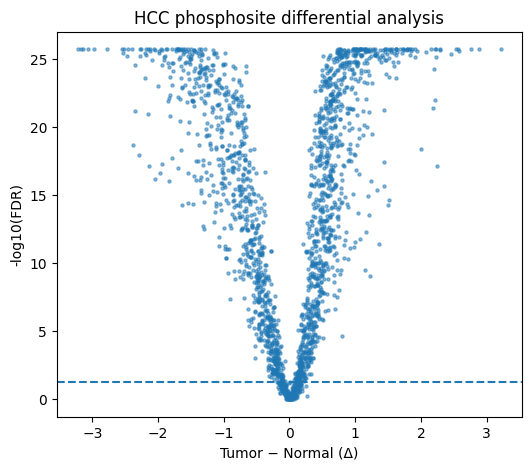

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

plt.scatter(
    summary["mean_delta"],
    -np.log10(summary["fdr"]),
    s=5, alpha=0.5
)

plt.axhline(-np.log10(0.05), linestyle="--")
plt.xlabel("Tumor − Normal (Δ)")
plt.ylabel("-log10(FDR)")
plt.title("HCC phosphosite differential analysis")

plt.show()


In [37]:
import os
print(os.getcwd())


/mnt/batch/tasks/shared/LS_root/mounts/clusters/barmoudeleyla1/code/HCC_project/notebooks


In [38]:
os.listdir("HCC_project/results")


['.amlignore',
 '.amlignore.amltmp',
 'all_sites_summary.csv',
 'module_summary.csv',
 'ranked_candidates.csv',
 'res.csv',
 'tumor_specific_sites.csv']

In [47]:
ph_t["protein"].head()

0    ENSP00000000412.3
1    ENSP00000003302.4
2    ENSP00000004982.3
3    ENSP00000005260.8
4    ENSP00000005340.4
Name: protein, dtype: object

In [48]:
ph_t["gene"].head()

0     ENSG00000003056.8
1    ENSG00000048028.11
2    ENSG00000004776.13
3    ENSG00000006453.14
4    ENSG00000004975.12
Name: gene, dtype: object

In [39]:
!pip install gseapy mygene


In [42]:
# Convert ENSG --> gene symbol
import mygene

mg = mygene.MyGeneInfo()

genes = ph_t["gene"].astype(str).unique().tolist()

# remove version (.8)
genes = [g.split(".")[0] for g in genes]

res = mg.querymany(
    genes,
    scopes="ensembl.gene",
    fields="symbol",
    species="human"
)

map_df = (
    pd.DataFrame(res)[["query","symbol"]]
    .dropna()
    .drop_duplicates()
)

map_df.head()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
5 input query terms found no hit:	['ENSG00000130723', 'ENSG00000148362', 'ENSG00000263264', 'ENSG00000168078', 'ENSG00000215271']


,query,symbol
0,ENSG00000003056,M6PR
1,ENSG00000048028,USP28
2,ENSG00000004776,HSPB6
3,ENSG00000006453,BAIAP2L1
4,ENSG00000004975,DVL2


In [43]:
summary["gene"] = summary["phosphosite_id"].str.split("_").str[0]

summary["gene_clean"] = summary["gene"].str.split(".").str[0]

summary = summary.merge(
    map_df,
    left_on="gene_clean",
    right_on="query",
    how="left"
)

summary.head()


,phosphosite_id,module,mean_delta,p,n,fdr,degree,score,gene,gene_clean,query,symbol
0,ENSP00000004982.3_S16,0,-1.125002,2.181684e-25,165,4.286368e-24,4,67.500094,ENSP00000004982.3,ENSP00000004982,NaN,NaN
1,ENSP00000280772.1_S1459,0,-1.785853,6.317931e-27,165,2.098944e-25,6,150.011659,ENSP00000280772.1,ENSP00000280772,NaN,NaN
2,ENSP00000316029.9_S883,0,-0.583400,7.558837e-15,165,3.138999e-14,22,160.838208,ENSP00000316029.9,ENSP00000316029,NaN,NaN
3,ENSP00000319141.4_S260,0,-0.775230,5.147591e-17,165,2.680416e-16,14,139.540022,ENSP00000319141.4,ENSP00000319141,NaN,NaN
4,ENSP00000333938.7_S80,0,-1.204707,3.121924e-20,165,2.369824e-19,57,838.476119,ENSP00000333938.7,ENSP00000333938,NaN,NaN


In [44]:
!pip -q install mygene

import mygene, pandas as pd

mg = mygene.MyGeneInfo()

genes_ensg = pd.Series(ph_t["gene"].astype(str).unique())
genes_ensg = genes_ensg.str.split(".").str[0].tolist()

res = mg.querymany(
    genes_ensg,
    scopes="ensembl.gene",
    fields="symbol",
    species="human"
)

map_df = (
    pd.DataFrame(res)[["query","symbol"]]
    .dropna()
    .drop_duplicates()
)

print("Mapped:", map_df.shape[0], "of", len(genes_ensg))
map_df.head()



Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Mapped: 8542 of 8548


,query,symbol
0,ENSG00000003056,M6PR
1,ENSG00000048028,USP28
2,ENSG00000004776,HSPB6
3,ENSG00000006453,BAIAP2L1
4,ENSG00000004975,DVL2


In [45]:
ensg_to_symbol = dict(zip(map_df["query"], map_df["symbol"]))



In [46]:
genes_symbol = [ensg_to_symbol.get(g, None) for g in genes_ensg]
genes_symbol = [g for g in genes_symbol if g is not None]

print("Symbols:", len(genes_symbol))
print(genes_symbol[:10])


Symbols: 8542
['M6PR', 'USP28', 'HSPB6', 'BAIAP2L1', 'DVL2', 'OSBPL7', 'HIVEP2', 'MAP4K5', 'PTBP1', 'ADARB1']


In [47]:
genes_symbol

['M6PR',
 'USP28',
 'HSPB6',
 'BAIAP2L1',
 'DVL2',
 'OSBPL7',
 'HIVEP2',
 'MAP4K5',
 'PTBP1',
 'ADARB1',
 'RB1CC1',
 'OTC',
 'BOD1L1',
 'RIPOR1',
 'RCN1',
 'ARHGEF5',
 'IL1RAP',
 'HDAC7',
 'OTUD5',
 'GPKOW',
 'LMCD1',
 'CAMSAP3',
 'BCAR1',
 'BCL3',
 'SPP2',
 'REXO1',
 'STK10',
 'CDK13',
 'TMEM131',
 'NR1H4',
 'OSTM1',
 'ACTN1',
 'RALGAPA2',
 'GMIP',
 'MLF2',
 'XYLB',
 'AAAS',
 'CBX5',
 'BAG6',
 'VCL',
 'SIRT1',
 'SNAP29',
 'SF3A1',
 'MAPK1',
 'ANKRD54',
 'MICALL1',
 'MYH9',
 'RIPK3',
 'HSP90AA1',
 'SUPT16H',
 'FKBP3',
 'PYGL',
 'PSMA3',
 'PCK2',
 'PNN',
 'PTPRA',
 'NSFL1C',
 'TPD52L2',
 'SNTA1',
 'TXNL1',
 'PGRMC1',
 'HTATSF1',
 'NTHL1',
 'USP10',
 'TSC2',
 'STUB1',
 'CAPN15',
 'BCKDK',
 'KAT8',
 'DNAJC17',
 'RIPK2',
 'GDAP1',
 'CHRAC1',
 'UBR5',
 'CNOT3',
 'PNPLA6',
 'PAF1',
 'HNRNPL',
 'CLASRP',
 'FCGRT',
 'PEX11G',
 'TLE5',
 'SGTA',
 'FBL',
 'TBCB',
 'CACTIN',
 'SULT2A1',
 'RASIP1',
 'LENG1',
 'RPL18A',
 'SIPA1L3',
 'NAMPT',
 'CAV2',
 'PDAP1',
 'GLCCI1',
 'CLIP2',
 'SEC61B',
 'SETX'

In [49]:
enr = gp.enrichr(
    gene_list=genes_symbol,
    gene_sets=["KEA_2015"],
    organism="Human",
    outdir=None
)

enr.results.head(15)


NameError: name 'gp' is not defined

In [57]:
enr.results.to_csv("HCC_project/results/res.csv")


NameError: name 'enr' is not defined

In [50]:
df = pd.read_csv("HCC_project/results/res.csv")

In [51]:
map_df.head()

,query,symbol
0,ENSG00000003056,M6PR
1,ENSG00000048028,USP28
2,ENSG00000004776,HSPB6
3,ENSG00000006453,BAIAP2L1
4,ENSG00000004975,DVL2


In [52]:
df.head()

,Unnamed: 0,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,0,KEA_2015,CDK2,463/553,1.641274e-90,6.400969e-88,0,0,7.238773,1496.523490,RB1;USP6NL;ATF2;MDC1;ANKLE2;NUP107;POP1;RAPH1;...
1,1,KEA_2015,GSK3B,438/527,1.723525e-83,3.360874e-81,0,0,6.904098,1315.715246,RB1;POP1;ITSN1;TESK1;RAPH1;SMC4;ELK1;ELK3;MYLK...
2,2,KEA_2015,CDK1,401/494,1.623527e-70,2.110585e-68,0,0,6.019399,967.295433,RB1;GJA1;PPP4R2;DPYSL2;MYC;STMN1;JUNB;NFRKB;UN...
3,3,KEA_2015,MAPK14,328/396,7.671338e-62,7.479554e-60,0,0,6.688580,941.235670,RB1;ATF2;CCNK;ZMYND8;MKI67;ELK1;ELK3;RPS6KA4;L...
4,4,KEA_2015,MAPK1,265/326,4.964078e-47,3.871981e-45,0,0,5.981824,637.777721,ATF2;RAPH1;SMC4;ELK1;MYLK;RPS6KA4;LIPE;RPS6KA3...


In [53]:

print(df.columns)




Index(['Unnamed: 0', 'Gene_set', 'Term', 'Overlap', 'P-value',
       'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio',
       'Combined Score', 'Genes'],
      dtype='object')


In [55]:
sig_kinases = df[df["Adjusted P-value"] < 0.01]


In [56]:
print(len(df))
print(len(sig_kinases))


390
108


In [57]:
sig_kinases.sort_values("Adjusted P-value").head(10)




,Unnamed: 0,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,0,KEA_2015,CDK2,463/553,1.641274e-90,6.400969e-88,0,0,7.238773,1496.523490,RB1;USP6NL;ATF2;MDC1;ANKLE2;NUP107;POP1;RAPH1;...
1,1,KEA_2015,GSK3B,438/527,1.723525e-83,3.360874e-81,0,0,6.904098,1315.715246,RB1;POP1;ITSN1;TESK1;RAPH1;SMC4;ELK1;ELK3;MYLK...
2,2,KEA_2015,CDK1,401/494,1.623527e-70,2.110585e-68,0,0,6.019399,967.295433,RB1;GJA1;PPP4R2;DPYSL2;MYC;STMN1;JUNB;NFRKB;UN...
3,3,KEA_2015,MAPK14,328/396,7.671338e-62,7.479554e-60,0,0,6.688580,941.235670,RB1;ATF2;CCNK;ZMYND8;MKI67;ELK1;ELK3;RPS6KA4;L...
4,4,KEA_2015,MAPK1,265/326,4.964078e-47,3.871981e-45,0,0,5.981824,637.777721,ATF2;RAPH1;SMC4;ELK1;MYLK;RPS6KA4;LIPE;RPS6KA3...
5,5,KEA_2015,MAPK8,190/225,1.261618e-38,8.200516e-37,0,0,7.424637,647.917208,ATF2;APP;CCNT2;IRS1;CTNND2;ATN1;PRDM2;IRS2;NR3...
6,6,KEA_2015,RPS6KA3,251/332,1.164977e-34,6.490585e-33,0,0,4.252159,332.243298,TRRAP;WIPF1;ITSN1;MYLK;PNN;LIPE;RPS6KA3;CDC23;...
7,7,KEA_2015,AKT1,172/210,1.019234e-31,4.968766e-30,0,0,6.175690,440.703956,TP53RK;NCF1;IRS1;CTNND2;ITSN1;NCF4;HJURP;IRS2;...
8,8,KEA_2015,CSNK2A1,216/286,6.957442e-30,3.014891e-28,0,0,4.220528,283.356701,ATF1;MDC1;SPI1;CCNH;SLC4A1;IKZF1;F11R;SMC3;RPS...
9,9,KEA_2015,CHEK1,120/137,5.670213e-28,2.211383e-26,0,0,9.589171,601.597329,RB1;MDC1;RIF1;POP4;HDLBP;CWC25;CAAP1;MKI67;GOL...


In [58]:
print(df.columns)
print(df["Adjusted P-value"].min(), df["Adjusted P-value"].max())


Index(['Unnamed: 0', 'Gene_set', 'Term', 'Overlap', 'P-value',
       'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio',
       'Combined Score', 'Genes'],
      dtype='object')
6.400969029953707e-88 0.8922985814979476


In [59]:
sig_kinases.sort_values("Adjusted P-value").head(5)[["Term","Adjusted P-value","Overlap"]]



,Term,Adjusted P-value,Overlap
0,CDK2,6.400969e-88,463/553
1,GSK3B,3.360874e-81,438/527
2,CDK1,2.110585e-68,401/494
3,MAPK14,7.479554e-60,328/396
4,MAPK1,3.871981e-45,265/326


In [60]:
import pandas as pd
import numpy as np
import re

enr = pd.read_csv("HCC_project/results/res.csv")
if "Unnamed: 0" in enr.columns:
    enr = enr.drop(columns=["Unnamed: 0"])


In [61]:
def parse_gene_list(x):
    if pd.isna(x):
        return set()
    # Enrichr sometimes uses ';' or ','; occasionally tabs/newlines
    parts = re.split(r"[;, \t\n]+", str(x).strip())
    parts = [p for p in parts if p]  # remove empty
    return set(parts)


In [62]:
cdk2_genes = parse_gene_list(enr.loc[enr["Term"]=="CDK2", "Genes"].iloc[0])
cdk1_genes = parse_gene_list(enr.loc[enr["Term"]=="CDK1", "Genes"].iloc[0])

# union = overall CDK substrate signal
cdk_genes = cdk1_genes | cdk2_genes

print("CDK2 genes:", len(cdk2_genes))
print("CDK1 genes:", len(cdk1_genes))
print("CDK union:", len(cdk_genes))


CDK2 genes: 463
CDK1 genes: 401
CDK union: 691


In [78]:
#print(summary.columns)
#print("symbol NA rate:", summary["symbol"].isna().mean() if "symbol" in summary.columns else "NO symbol column")
#print("n rows:", len(summary))


In [63]:
import pandas as pd

# ensure phosphosite_id exists in ph_t
if "phosphosite_id" not in ph_t.columns:
    ph_t["phosphosite_id"] = ph_t["protein"].astype(str) + "_" + ph_t["site"].astype(str)

site_to_ensg = (
    ph_t[["phosphosite_id", "gene"]]
    .drop_duplicates()
    .copy()
)

site_to_ensg["gene_clean"] = site_to_ensg["gene"].astype(str).str.split(".").str[0]
site_to_ensg.head()


,phosphosite_id,gene,gene_clean
0,ENSP00000000412.3_S267,ENSG00000003056.8,ENSG00000003056
1,ENSP00000003302.4_S1053,ENSG00000048028.11,ENSG00000048028
2,ENSP00000004982.3_S16,ENSG00000004776.13,ENSG00000004776
3,ENSP00000005260.8_S261,ENSG00000006453.14,ENSG00000006453
4,ENSP00000005340.4_S170,ENSG00000004975.12,ENSG00000004975


In [64]:
# Ensure symbol is present and not missing
symbol = genes_symbol
df = summary.dropna(subset=["symbol", "module"]).copy()

module_cdk = (
    df.groupby("module")["symbol"]
      .apply(lambda s: len(set(s) & cdk_genes))   # overlap count
      .rename("cdk_overlap_genes")
      .to_frame()
)

module_sizes = df.groupby("module")["symbol"].nunique().rename("module_n_genes")
module_cdk = module_cdk.join(module_sizes)

module_cdk["cdk_fraction"] = module_cdk["cdk_overlap_genes"] / module_cdk["module_n_genes"]

module_cdk.sort_values(["cdk_overlap_genes","cdk_fraction"], ascending=False).head(10)


/tmp/ipykernel_3291/2737920128.py:7: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda s: len(set(s) & cdk_genes))   # overlap count


,cdk_overlap_genes,module_n_genes,cdk_fraction
module,,,


In [65]:
!pip -q install mygene
import mygene

mg = mygene.MyGeneInfo()
ensg_list = site_to_ensg["gene_clean"].unique().tolist()

res = mg.querymany(ensg_list, scopes="ensembl.gene", fields="symbol", species="human")
map_df = pd.DataFrame(res)[["query","symbol"]].dropna().drop_duplicates()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
5 input query terms found no hit:	['ENSG00000130723', 'ENSG00000148362', 'ENSG00000263264', 'ENSG00000168078', 'ENSG00000215271']


In [66]:
site_to_symbol = site_to_ensg.merge(map_df, left_on="gene_clean", right_on="query", how="left")

print("symbol NA rate in mapping:", site_to_symbol["symbol"].isna().mean())
site_to_symbol.head()


symbol NA rate in mapping: 0.0009853068280034573


,phosphosite_id,gene,gene_clean,query,symbol
0,ENSP00000000412.3_S267,ENSG00000003056.8,ENSG00000003056,ENSG00000003056,M6PR
1,ENSP00000003302.4_S1053,ENSG00000048028.11,ENSG00000048028,ENSG00000048028,USP28
2,ENSP00000004982.3_S16,ENSG00000004776.13,ENSG00000004776,ENSG00000004776,HSPB6
3,ENSP00000005260.8_S261,ENSG00000006453.14,ENSG00000006453,ENSG00000006453,BAIAP2L1
4,ENSP00000005340.4_S170,ENSG00000004975.12,ENSG00000004975,ENSG00000004975,DVL2


In [75]:
map_df

,query,symbol
0,ENSG00000003056,M6PR
1,ENSG00000048028,USP28
2,ENSG00000004776,HSPB6
3,ENSG00000006453,BAIAP2L1
4,ENSG00000004975,DVL2
...,...,...
8543,ENSG00000109762,SNX25
8544,ENSG00000176406,RIMS2
8545,ENSG00000074266,EED
8546,ENSG00000103248,MTHFSD


In [79]:
site_to_symbol = site_to_ensg.merge(map_df, left_on="gene_clean", right_on="query", how="left")

print("symbol NA rate in mapping:", site_to_symbol["symbol"].isna().mean())
site_to_symbol.head()


symbol NA rate in mapping: 0.0009853068280034573


,phosphosite_id,gene,gene_clean,query,symbol
0,ENSP00000000412.3_S267,ENSG00000003056.8,ENSG00000003056,ENSG00000003056,M6PR
1,ENSP00000003302.4_S1053,ENSG00000048028.11,ENSG00000048028,ENSG00000048028,USP28
2,ENSP00000004982.3_S16,ENSG00000004776.13,ENSG00000004776,ENSG00000004776,HSPB6
3,ENSP00000005260.8_S261,ENSG00000006453.14,ENSG00000006453,ENSG00000006453,BAIAP2L1
4,ENSP00000005340.4_S170,ENSG00000004975.12,ENSG00000004975,ENSG00000004975,DVL2


In [81]:
summary = summary.merge(
    site_to_symbol[["phosphosite_id","gene_clean","symbol"]],
    on="phosphosite_id",
    how="left"
)

print("summary symbol NA rate:", summary["symbol"].isna().mean())
summary[["phosphosite_id","symbol","module","mean_delta","fdr"]].head()


summary symbol NA rate: 0.0009689922480620155


,phosphosite_id,symbol,module,mean_delta,fdr
0,ENSP00000004982.3_S16,HSPB6,0,-1.125002,4.286368e-24
1,ENSP00000280772.1_S1459,ANK3,0,-1.785853,2.098944e-25
2,ENSP00000316029.9_S883,TLN1,0,-0.583400,3.138999e-14
3,ENSP00000319141.4_S260,CYBRD1,0,-0.775230,2.680416e-16
4,ENSP00000333938.7_S80,NEXN,0,-1.204707,2.369824e-19


In [82]:
df = summary.dropna(subset=["symbol","module"]).copy()

module_cdk = (
    df.groupby("module", group_keys=False)["symbol"]
      .apply(lambda s: len(set(s) & cdk_genes))
      .rename("cdk_overlap_genes")
      .to_frame()
)

module_sizes = df.groupby("module")["symbol"].nunique().rename("module_n_genes")
module_cdk = module_cdk.join(module_sizes)

module_cdk["cdk_fraction"] = module_cdk["cdk_overlap_genes"] / module_cdk["module_n_genes"]

module_cdk.sort_values(["cdk_overlap_genes","cdk_fraction"], ascending=False).head(10)


,cdk_overlap_genes,module_n_genes,cdk_fraction
module,,,
1,45,126,0.357143
5,23,93,0.247312
21,21,65,0.323077
34,13,61,0.213115
10,13,89,0.146067
0,11,61,0.180328
15,8,39,0.205128
24,6,35,0.171429
17,5,43,0.116279


In [83]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

# Universe = all unique genes in the network summary
universe = set(df["symbol"].unique())
M = len(universe)                 # population size
K = len(cdk_genes & universe)     # CDK genes present in your universe

rows = []
for m, sub in df.groupby("module"):
    genes_m = set(sub["symbol"].unique())
    n = len(genes_m)                   # module size
    k = len(genes_m & cdk_genes)       # hits in module
    # P(X >= k) enrichment p-value
    p = hypergeom.sf(k-1, M, K, n)
    rows.append((m, n, k, p))

cdk_enr = pd.DataFrame(rows, columns=["module","module_n_genes","cdk_hits","p"])
cdk_enr["fdr"] = multipletests(cdk_enr["p"], method="fdr_bh")[1]
cdk_enr = cdk_enr.sort_values(["fdr","cdk_hits"], ascending=True)

cdk_enr.head(15)


,module,module_n_genes,cdk_hits,p,fdr
1,1,126,45,0.000006,0.002424
14,14,1,1,0.200000,0.979487
19,19,1,1,0.200000,0.979487
43,43,1,1,0.200000,0.979487
70,70,1,1,0.200000,0.979487
75,75,1,1,0.200000,0.979487
77,77,1,1,0.200000,0.979487
78,78,1,1,0.200000,0.979487
94,94,1,1,0.200000,0.979487
95,95,1,1,0.200000,0.979487


In [84]:
top_modules = cdk_enr.query("fdr < 0.05").head(5)["module"].tolist()
top_modules


[1]

In [85]:
dark_candidates = (
    summary[summary["module"].isin(top_modules)]
    .sort_values("score", ascending=False)
    .head(50)
)

dark_candidates[["phosphosite_id","symbol","module","mean_delta","fdr","degree","score"]].head(20)


,phosphosite_id,symbol,module,mean_delta,fdr,degree,score
10,ENSP00000468156.1_S382,ILF3,1,1.721878,2.085993e-26,43,909.151474
200,ENSP00000371321.1_S368,RFC1,1,1.865994,2.085993e-26,27,626.973923
193,ENSP00000318195.4_S67,NCL,1,1.736460,2.227644e-26,28,604.288122
204,ENSP00000446880.1_S1783,BAZ2A,1,1.377643,7.192664e-26,32,545.546805
195,ENSP00000329662.4_S31,H1-10,1,1.403999,5.259474e-26,26,454.895697
7,ENSP00000367028.4_S1378,TCOF1,1,1.550041,2.359158e-26,20,390.610226
199,ENSP00000367028.4_T1270,TCOF1,1,2.155127,2.085993e-26,14,387.922894
188,ENSP00000221232.5_S299,CNOT3,1,1.528591,2.085993e-26,19,366.861922
453,ENSP00000339566.3_T146,H1-2,1,2.540444,2.085993e-26,9,304.853287
191,ENSP00000265295.4_S555,SPDL1,1,1.840666,2.085993e-26,12,287.143920


In [86]:
cdk_enr.head(10)


,module,module_n_genes,cdk_hits,p,fdr
1,1,126,45,0.000006,0.002424
14,14,1,1,0.200000,0.979487
19,19,1,1,0.200000,0.979487
43,43,1,1,0.200000,0.979487
70,70,1,1,0.200000,0.979487
75,75,1,1,0.200000,0.979487
77,77,1,1,0.200000,0.979487
78,78,1,1,0.200000,0.979487
94,94,1,1,0.200000,0.979487
95,95,1,1,0.200000,0.979487


In [87]:
cdk_module = summary[summary["module"] == 1]
cdk_module = cdk_module.sort_values("mean_delta", ascending=False)

cdk_module.head(20)


,phosphosite_id,module,mean_delta,p,n,fdr,degree,score,gene,gene_clean_x,query,symbol_x,gene_clean_y,symbol_y,gene_clean,symbol
1162,ENSP00000339566.3_T31,1,2.878159,1.003420e-28,165,2.085993e-26,5,207.227473,ENSP00000339566.3,ENSP00000339566,NaN,NaN,ENSG00000187837,H1-2,ENSG00000187837,H1-2
1161,ENSP00000307705.4_T146,1,2.567476,8.360370e-29,165,2.085993e-26,3,123.238840,ENSP00000307705.4,ENSP00000307705,NaN,NaN,ENSG00000168298,H1-4,ENSG00000168298,H1-4
453,ENSP00000339566.3_T146,1,2.540444,8.831097e-29,165,2.085993e-26,9,304.853287,ENSP00000339566.3,ENSP00000339566,NaN,NaN,ENSG00000187837,H1-2,ENSG00000187837,H1-2
192,ENSP00000271452.3_S247,1,2.283907,8.060470e-29,165,2.085993e-26,8,246.661968,ENSP00000271452.3,ENSP00000271452,NaN,NaN,ENSG00000143228,NUF2,ENSG00000143228,NUF2
454,ENSP00000411532.1_S1106,1,2.236147,1.893618e-27,165,8.031346e-26,3,107.335062,ENSP00000411532.1,ENSP00000411532,NaN,NaN,ENSG00000131747,TOP2A,ENSG00000131747,TOP2A
196,ENSP00000356110.4_S181,1,2.221974,7.914547e-29,165,2.085993e-26,5,159.982158,ENSP00000356110.4,ENSP00000356110,NaN,NaN,ENSG00000069275,NUCKS1,ENSG00000069275,NUCKS1
199,ENSP00000367028.4_T1270,1,2.155127,1.003420e-28,165,2.085993e-26,14,387.922894,ENSP00000367028.4,ENSP00000367028,NaN,NaN,ENSG00000070814,TCOF1,ENSG00000070814,TCOF1
1652,ENSP00000402084.2_S150,1,2.077019,5.217724e-28,165,3.448492e-26,2,74.772690,ENSP00000402084.2,ENSP00000402084,NaN,NaN,ENSG00000166483,WEE1,ENSG00000166483,WEE1
189,ENSP00000251496.2_S674,1,1.907820,1.642038e-27,165,7.192664e-26,7,183.150709,ENSP00000251496.2,ENSP00000251496,NaN,NaN,ENSG00000109805,NCAPG,ENSG00000109805,NCAPG
200,ENSP00000371321.1_S368,1,1.865994,8.831097e-29,165,2.085993e-26,27,626.973923,ENSP00000371321.1,ENSP00000371321,NaN,NaN,ENSG00000035928,RFC1,ENSG00000035928,RFC1


In [89]:
dark_cdk = cdk_module.sort_values("score", ascending=False).head(20)
dark_cdk[["phosphosite_id","symbol","mean_delta","degree","score"]]


,phosphosite_id,symbol,mean_delta,degree,score
10,ENSP00000468156.1_S382,ILF3,1.721878,43,909.151474
200,ENSP00000371321.1_S368,RFC1,1.865994,27,626.973923
193,ENSP00000318195.4_S67,NCL,1.736460,28,604.288122
204,ENSP00000446880.1_S1783,BAZ2A,1.377643,32,545.546805
195,ENSP00000329662.4_S31,H1-10,1.403999,26,454.895697
7,ENSP00000367028.4_S1378,TCOF1,1.550041,20,390.610226
199,ENSP00000367028.4_T1270,TCOF1,2.155127,14,387.922894
188,ENSP00000221232.5_S299,CNOT3,1.528591,19,366.861922
453,ENSP00000339566.3_T146,H1-2,2.540444,9,304.853287
191,ENSP00000265295.4_S555,SPDL1,1.840666,12,287.143920


In [90]:
summary[["phosphosite_id","symbol","module"]].head(10)



,phosphosite_id,symbol,module
0,ENSP00000004982.3_S16,HSPB6,0
1,ENSP00000280772.1_S1459,ANK3,0
2,ENSP00000316029.9_S883,TLN1,0
3,ENSP00000319141.4_S260,CYBRD1,0
4,ENSP00000333938.7_S80,NEXN,0
5,ENSP00000014112.5_S141,PTBP1,1
6,ENSP00000342434.4_S312,BAZ1B,1
7,ENSP00000367028.4_S1378,TCOF1,1
8,ENSP00000397552.2_S233,ACTL6A,1
9,ENSP00000435210.1_S496,BCLAF1,1


In [91]:
cdk_module = summary[summary["module"] == 1].copy()

tumor_up = cdk_module[
    (cdk_module["fdr"] < 0.05) &
    (cdk_module["mean_delta"] > 0)
].copy()

tumor_up = tumor_up.sort_values("score", ascending=False)

tumor_up[["phosphosite_id","symbol","mean_delta","fdr","degree","score"]].head(20)


,phosphosite_id,symbol,mean_delta,fdr,degree,score
10,ENSP00000468156.1_S382,ILF3,1.721878,2.085993e-26,43,909.151474
200,ENSP00000371321.1_S368,RFC1,1.865994,2.085993e-26,27,626.973923
193,ENSP00000318195.4_S67,NCL,1.736460,2.227644e-26,28,604.288122
204,ENSP00000446880.1_S1783,BAZ2A,1.377643,7.192664e-26,32,545.546805
195,ENSP00000329662.4_S31,H1-10,1.403999,5.259474e-26,26,454.895697
7,ENSP00000367028.4_S1378,TCOF1,1.550041,2.359158e-26,20,390.610226
199,ENSP00000367028.4_T1270,TCOF1,2.155127,2.085993e-26,14,387.922894
188,ENSP00000221232.5_S299,CNOT3,1.528591,2.085993e-26,19,366.861922
453,ENSP00000339566.3_T146,H1-2,2.540444,2.085993e-26,9,304.853287
191,ENSP00000265295.4_S555,SPDL1,1.840666,2.085993e-26,12,287.143920


In [93]:
known_cellcycle = [
    "CDK1","CDK2","CCNB1","CCNB2","RB1",
    "MCM2","MCM3","MCM4","MCM5","MCM6","MCM7",
    "CDC6","CDC20","CDC25A","CDC25B","CDC25C"
]

dark_candidates = tumor_up[
    ~tumor_up["symbol"].isin(known_cellcycle)
].copy()

dark_candidates.head(15)


,phosphosite_id,module,mean_delta,p,n,fdr,degree,score,gene,gene_clean_x,query,symbol_x,gene_clean_y,symbol_y,gene_clean,symbol
10,ENSP00000468156.1_S382,1,1.721878,8.209061e-29,165,2.085993e-26,43,909.151474,ENSP00000468156.1,ENSP00000468156,NaN,NaN,ENSG00000129351,ILF3,ENSG00000129351,ILF3
200,ENSP00000371321.1_S368,1,1.865994,8.831097e-29,165,2.085993e-26,27,626.973923,ENSP00000371321.1,ENSP00000371321,NaN,NaN,ENSG00000035928,RFC1,ENSG00000035928,RFC1
193,ENSP00000318195.4_S67,1,1.736460,2.444523e-28,165,2.227644e-26,28,604.288122,ENSP00000318195.4,ENSP00000318195,NaN,NaN,ENSG00000115053,NCL,ENSG00000115053,NCL
204,ENSP00000446880.1_S1783,1,1.377643,1.642038e-27,165,7.192664e-26,32,545.546805,ENSP00000446880.1,ENSP00000446880,NaN,NaN,ENSG00000076108,BAZ2A,ENSG00000076108,BAZ2A
195,ENSP00000329662.4_S31,1,1.403999,1.031986e-27,165,5.259474e-26,26,454.895697,ENSP00000329662.4,ENSP00000329662,NaN,NaN,ENSG00000184897,H1-10,ENSG00000184897,H1-10
7,ENSP00000367028.4_S1378,1,1.550041,2.825339e-28,165,2.359158e-26,20,390.610226,ENSP00000367028.4,ENSP00000367028,NaN,NaN,ENSG00000070814,TCOF1,ENSG00000070814,TCOF1
199,ENSP00000367028.4_T1270,1,2.155127,1.003420e-28,165,2.085993e-26,14,387.922894,ENSP00000367028.4,ENSP00000367028,NaN,NaN,ENSG00000070814,TCOF1,ENSG00000070814,TCOF1
188,ENSP00000221232.5_S299,1,1.528591,8.209061e-29,165,2.085993e-26,19,366.861922,ENSP00000221232.5,ENSP00000221232,NaN,NaN,ENSG00000088038,CNOT3,ENSG00000088038,CNOT3
453,ENSP00000339566.3_T146,1,2.540444,8.831097e-29,165,2.085993e-26,9,304.853287,ENSP00000339566.3,ENSP00000339566,NaN,NaN,ENSG00000187837,H1-2,ENSG00000187837,H1-2
191,ENSP00000265295.4_S555,1,1.840666,1.294945e-28,165,2.085993e-26,12,287.143920,ENSP00000265295.4,ENSP00000265295,NaN,NaN,ENSG00000040275,SPDL1,ENSG00000040275,SPDL1


In [94]:
tumor_up.head(10)


,phosphosite_id,module,mean_delta,p,n,fdr,degree,score,gene,gene_clean_x,query,symbol_x,gene_clean_y,symbol_y,gene_clean,symbol
10,ENSP00000468156.1_S382,1,1.721878,8.209061e-29,165,2.085993e-26,43,909.151474,ENSP00000468156.1,ENSP00000468156,NaN,NaN,ENSG00000129351,ILF3,ENSG00000129351,ILF3
200,ENSP00000371321.1_S368,1,1.865994,8.831097e-29,165,2.085993e-26,27,626.973923,ENSP00000371321.1,ENSP00000371321,NaN,NaN,ENSG00000035928,RFC1,ENSG00000035928,RFC1
193,ENSP00000318195.4_S67,1,1.736460,2.444523e-28,165,2.227644e-26,28,604.288122,ENSP00000318195.4,ENSP00000318195,NaN,NaN,ENSG00000115053,NCL,ENSG00000115053,NCL
204,ENSP00000446880.1_S1783,1,1.377643,1.642038e-27,165,7.192664e-26,32,545.546805,ENSP00000446880.1,ENSP00000446880,NaN,NaN,ENSG00000076108,BAZ2A,ENSG00000076108,BAZ2A
195,ENSP00000329662.4_S31,1,1.403999,1.031986e-27,165,5.259474e-26,26,454.895697,ENSP00000329662.4,ENSP00000329662,NaN,NaN,ENSG00000184897,H1-10,ENSG00000184897,H1-10
7,ENSP00000367028.4_S1378,1,1.550041,2.825339e-28,165,2.359158e-26,20,390.610226,ENSP00000367028.4,ENSP00000367028,NaN,NaN,ENSG00000070814,TCOF1,ENSG00000070814,TCOF1
199,ENSP00000367028.4_T1270,1,2.155127,1.003420e-28,165,2.085993e-26,14,387.922894,ENSP00000367028.4,ENSP00000367028,NaN,NaN,ENSG00000070814,TCOF1,ENSG00000070814,TCOF1
188,ENSP00000221232.5_S299,1,1.528591,8.209061e-29,165,2.085993e-26,19,366.861922,ENSP00000221232.5,ENSP00000221232,NaN,NaN,ENSG00000088038,CNOT3,ENSG00000088038,CNOT3
453,ENSP00000339566.3_T146,1,2.540444,8.831097e-29,165,2.085993e-26,9,304.853287,ENSP00000339566.3,ENSP00000339566,NaN,NaN,ENSG00000187837,H1-2,ENSG00000187837,H1-2
191,ENSP00000265295.4_S555,1,1.840666,1.294945e-28,165,2.085993e-26,12,287.143920,ENSP00000265295.4,ENSP00000265295,NaN,NaN,ENSG00000040275,SPDL1,ENSG00000040275,SPDL1


In [95]:
tumor_up.to_csv("HCC_project/results/novel_dark_phospho.csv")

In [96]:
for g in ["GENE_A","GENE_B","GENE_C"]:
    print(summary[summary["symbol"] == g][["phosphosite_id","mean_delta","degree"]])


Empty DataFrame
Columns: [phosphosite_id, mean_delta, degree]
Index: []
Empty DataFrame
Columns: [phosphosite_id, mean_delta, degree]
Index: []
Empty DataFrame
Columns: [phosphosite_id, mean_delta, degree]
Index: []


In [97]:
top_genes = tumor_up["symbol"].head(10).unique()
print(top_genes)


['ILF3' 'RFC1' 'NCL' 'BAZ2A' 'H1-10' 'TCOF1' 'CNOT3' 'H1-2' 'SPDL1']


In [98]:
for g in top_genes[:5]:
    print("\nGene:", g)
    print(summary[summary["symbol"] == g][["phosphosite_id","mean_delta","degree"]])



Gene: ILF3
             phosphosite_id  mean_delta  degree
10   ENSP00000468156.1_S382    1.721878      43
130   ENSP00000468156.1_S62    0.578010       1
635  ENSP00000468156.1_S482    0.543057       1

Gene: RFC1
             phosphosite_id  mean_delta  degree
200  ENSP00000371321.1_S368    1.865994      27

Gene: NCL
              phosphosite_id  mean_delta  degree
193    ENSP00000318195.4_S67    1.736460      28
1244  ENSP00000318195.4_S619    0.624726       1
1246  ENSP00000318195.4_T106    1.329024       2

Gene: BAZ2A
              phosphosite_id  mean_delta  degree
204  ENSP00000446880.1_S1783    1.377643      32

Gene: H1-10
            phosphosite_id  mean_delta  degree
195  ENSP00000329662.4_S31    1.403999      26


In [99]:
tumor_up[["phosphosite_id","symbol","mean_delta","degree","score"]].head(10)


,phosphosite_id,symbol,mean_delta,degree,score
10,ENSP00000468156.1_S382,ILF3,1.721878,43,909.151474
200,ENSP00000371321.1_S368,RFC1,1.865994,27,626.973923
193,ENSP00000318195.4_S67,NCL,1.736460,28,604.288122
204,ENSP00000446880.1_S1783,BAZ2A,1.377643,32,545.546805
195,ENSP00000329662.4_S31,H1-10,1.403999,26,454.895697
7,ENSP00000367028.4_S1378,TCOF1,1.550041,20,390.610226
199,ENSP00000367028.4_T1270,TCOF1,2.155127,14,387.922894
188,ENSP00000221232.5_S299,CNOT3,1.528591,19,366.861922
453,ENSP00000339566.3_T146,H1-2,2.540444,9,304.853287
191,ENSP00000265295.4_S555,SPDL1,1.840666,12,287.143920


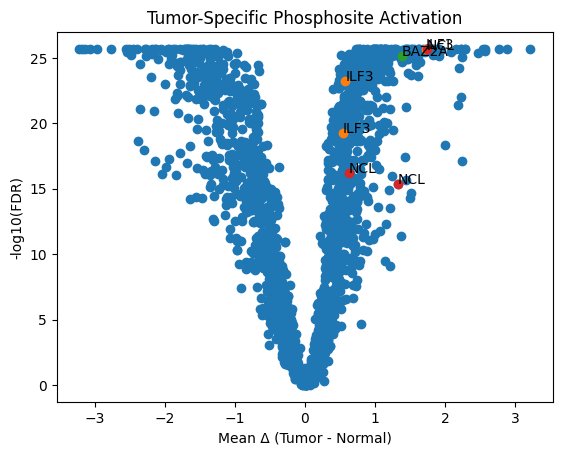

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
summary["neglog10_fdr"] = -np.log10(summary["fdr"])

candidates = ["ILF3","BAZ2A","NCL"]

plt.figure()
plt.scatter(summary["mean_delta"], summary["neglog10_fdr"])

# Highlight candidates
for g in candidates:
    sub = summary[summary["symbol"] == g]
    plt.scatter(sub["mean_delta"], sub["neglog10_fdr"])
    for _, row in sub.iterrows():
        plt.text(row["mean_delta"], row["neglog10_fdr"], g)

plt.xlabel("Mean Δ (Tumor - Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Tumor-Specific Phosphosite Activation")
plt.show()


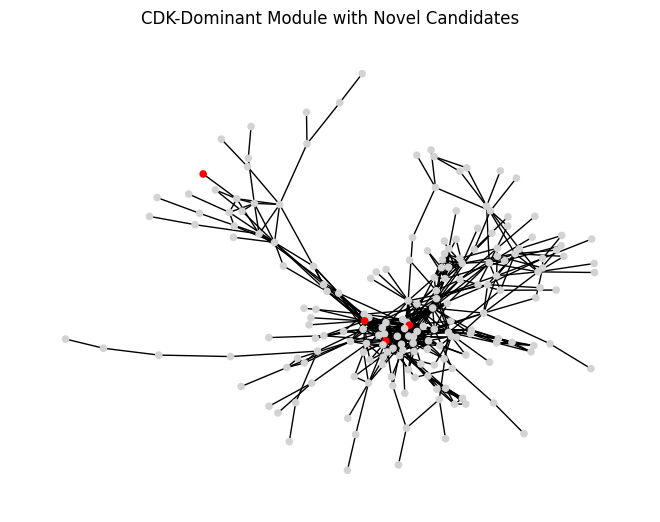

In [101]:
import networkx as nx

# Build subgraph for module 1
module1_nodes = summary[summary["module"]==1]["phosphosite_id"].tolist()
G1 = Gd.subgraph(module1_nodes)

# Node colors
colors = []
for node in G1.nodes():
    symbol = summary.loc[summary["phosphosite_id"]==node,"symbol"].values[0]
    if symbol in candidates:
        colors.append("red")
    else:
        colors.append("lightgray")

plt.figure()
nx.draw(G1, node_size=20, node_color=colors, with_labels=False)
plt.title("CDK-Dominant Module with Novel Candidates")
plt.show()


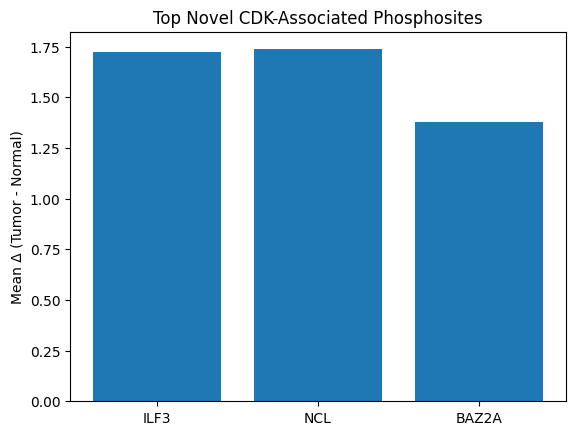

In [102]:
cand_df = summary[summary["symbol"].isin(candidates)]

plt.figure()
plt.bar(cand_df["symbol"], cand_df["mean_delta"])
plt.ylabel("Mean Δ (Tumor - Normal)")
plt.title("Top Novel CDK-Associated Phosphosites")
plt.show()


In [103]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [104]:
OUTPUT_DIR = "results/figures"   # change if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

CANDIDATES = {
    "ILF3": "ENSP00000468156.1_S382",
    "BAZ2A": "ENSP00000446880.1_S1783",
    "NCL": "ENSP00000318195.4_S67",
}
CAND_SYMBOLS = list(CANDIDATES.keys())
CAND_SITES = list(CANDIDATES.values())
CDK_TERMS = ["CDK2", "CDK1", "GSK3B", "MAPK14", "MAPK1"]

In [105]:
required_cols = {"phosphosite_id", "module", "mean_delta", "fdr", "degree", "symbol"}
missing = required_cols - set(summary.columns)
if missing:
    raise ValueError(f"summary is missing required columns: {missing}")

if not {"Term", "Adjusted P-value"}.issubset(enr.columns):
    raise ValueError("enr must contain columns: 'Term' and 'Adjusted P-value'")

# Prep common columns
summary = summary.copy()
summary["neglog10_fdr"] = -np.log10(summary["fdr"].astype(float) + 1e-300)

# Helpful lookup for symbol by phosphosite_id (for network labeling)
site2symbol = dict(zip(summary["phosphosite_id"], summary["symbol"]))

In [107]:
## fig1
def make_figure1(output_dir=OUTPUT_DIR):
    fig = plt.figure(figsize=(10, 4.2))
    ax = fig.add_subplot(111)
    ax.axis("off")

    # Panel A: Paired design
    ax.text(0.02, 0.85, "Figure 1. Study design & statistical framework", fontsize=14, fontweight="bold")
    ax.text(0.02, 0.70, "A) Paired design (n=165)", fontsize=11, fontweight="bold")
    ax.text(0.04, 0.62, "Tumor sample  ↔  Matched Normal sample", fontsize=11)
    ax.text(0.04, 0.55, "Δ = Tumor − Normal (per patient)", fontsize=10)
    ax.text(0.04, 0.48, "Paired Wilcoxon test + FDR correction", fontsize=10)

    # Panel B: Network construction
    ax.text(0.36, 0.70, "B) Differential signaling network", fontsize=11, fontweight="bold")
    ax.text(0.36, 0.62, "Δ matrix → Spearman correlation → threshold |ρ| ≥ 0.6", fontsize=10)
    ax.text(0.36, 0.55, "Edges = co-regulated phosphosites (tumor-specific)", fontsize=10)
    ax.text(0.36, 0.48, "Louvain community detection → modules (pathways)", fontsize=10)

    # Panel C: Kinase enrichment + prioritization
    ax.text(0.70, 0.70, "C) Kinase & candidate prioritization", fontsize=11, fontweight="bold")
    ax.text(0.70, 0.62, "KEA enrichment → CDK-dominant module", fontsize=10)
    ax.text(0.70, 0.55, "Rank sites by effect × significance × centrality", fontsize=10)
    ax.text(0.70, 0.48, "Highlight novel candidates (ILF3, BAZ2A, NCL)", fontsize=10)

    # Simple arrows (using annotate)
    ax.annotate("", xy=(0.33, 0.60), xytext=(0.25, 0.60), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(0.67, 0.60), xytext=(0.59, 0.60), arrowprops=dict(arrowstyle="->", lw=1.5))

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, "Figure1_framework.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(output_dir, "Figure1_framework.pdf"), dpi=300, bbox_inches="tight")
    plt.close(fig)



In [108]:
def make_figure2(summary, enr, output_dir=OUTPUT_DIR):
    fig = plt.figure(figsize=(11, 4.5))

    # 2A Volcano
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(summary["mean_delta"], summary["neglog10_fdr"], s=6, alpha=0.4)
    ax1.set_xlabel("Mean Δ (Tumor − Normal)")
    ax1.set_ylabel("-log10(FDR)")
    ax1.set_title("Figure 2A. Tumor-specific phosphosite changes")

    # Highlight candidates (no explicit colors; matplotlib defaults will differentiate)
    for sym, site in CANDIDATES.items():
        sub = summary[summary["phosphosite_id"] == site]
        if len(sub) == 0:
            continue
        ax1.scatter(sub["mean_delta"], sub["neglog10_fdr"], s=50)
        r = sub.iloc[0]
        ax1.text(r["mean_delta"], r["neglog10_fdr"], f" {sym}", fontsize=9)

    # 2B Top kinases
    ax2 = fig.add_subplot(1, 2, 2)

    # Keep only kinases we care about if present; otherwise take top 10
    enr2 = enr.copy()
    enr2 = enr2.dropna(subset=["Term", "Adjusted P-value"])
    enr2["Adjusted P-value"] = enr2["Adjusted P-value"].astype(float)

    subset = enr2[enr2["Term"].isin(CDK_TERMS)].copy()
    if subset.empty:
        subset = enr2.sort_values("Adjusted P-value").head(10).copy()

    subset = subset.sort_values("Adjusted P-value", ascending=True)
    y = -np.log10(subset["Adjusted P-value"] + 1e-300)
    ax2.bar(subset["Term"].astype(str), y)
    ax2.set_ylabel("-log10(Adjusted P-value)")
    ax2.set_title("Figure 2B. Kinase enrichment (KEA)")
    ax2.tick_params(axis="x", rotation=45)

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, "Figure2_global_and_kinases.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(output_dir, "Figure2_global_and_kinases.pdf"), dpi=300, bbox_inches="tight")
    plt.close(fig)

In [109]:
## fig3
def make_figure3(summary, Gd, output_dir=OUTPUT_DIR, module_id=1):
    fig = plt.figure(figsize=(13, 4.8))

    # 3A network
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.set_title("Figure 3A. CDK-dominant module subnetwork")

    module_nodes = summary.loc[summary["module"] == module_id, "phosphosite_id"].astype(str).tolist()
    G1 = Gd.subgraph(module_nodes).copy()

    if G1.number_of_nodes() == 0:
        ax1.text(0.5, 0.5, "Module subgraph is empty", ha="center", va="center")
        ax1.axis("off")
    else:
        # Layout (spring layout can be slow; k controls spacing)
        pos = nx.spring_layout(G1, seed=1, k=1/np.sqrt(max(G1.number_of_nodes(), 1)))

        # Draw all nodes small
        nx.draw_networkx_edges(G1, pos, ax=ax1, width=0.3, alpha=0.25)
        nx.draw_networkx_nodes(G1, pos, ax=ax1, node_size=15, alpha=0.6)
        cand_in_graph = [s for s in CAND_SITES if s in G1.nodes]
        if cand_in_graph:
            nx.draw_networkx_nodes(G1, pos, ax=ax1, nodelist=cand_in_graph, node_size=120, alpha=0.95)

            # Add labels for candidates
            labels = {}
            for sym, site in CANDIDATES.items():
                if site in G1.nodes:
                    labels[site] = sym
            nx.draw_networkx_labels(G1, pos, labels=labels, ax=ax1, font_size=9)

        ax1.axis("off")

    # 3B candidate activation
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.set_title("Figure 3B. Candidate tumor activation (Δ)")

    cand_df = summary[summary["phosphosite_id"].isin(CAND_SITES)].copy()
    # Keep order ILF3, BAZ2A, NCL
    cand_df["sym_order"] = cand_df["phosphosite_id"].map({v:k for k,v in CANDIDATES.items()})
    cand_df = cand_df.sort_values("sym_order")
    ax2.bar(cand_df["sym_order"], cand_df["mean_delta"])
    ax2.set_ylabel("Mean Δ (Tumor − Normal)")

    # annotate degree above bars
    for i, row in enumerate(cand_df.itertuples(index=False)):
        # row.sym_order, row.degree
        ax2.text(i, float(row.mean_delta), f"deg={int(row.degree)}", ha="center", va="bottom", fontsize=9)

    # 3C table
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.set_title("Figure 3C. Candidate summary")
    ax3.axis("off")

    table_df = cand_df[["sym_order", "phosphosite_id", "mean_delta", "degree", "module", "fdr"]].copy()
    table_df = table_df.rename(columns={
        "sym_order": "Gene",
        "phosphosite_id": "Phosphosite",
        "mean_delta": "Mean Δ",
        "degree": "Degree",
        "module": "Module",
        "fdr": "FDR"
    })

     # Round for display
    table_df["Mean Δ"] = table_df["Mean Δ"].astype(float).round(3)
    table_df["FDR"] = table_df["FDR"].astype(float).map(lambda x: f"{x:.2e}")

    tbl = ax3.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.3)

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, "Figure3_module_and_candidates.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(output_dir, "Figure3_module_and_candidates.pdf"), dpi=300, bbox_inches="tight")
    plt.close(fig)


In [110]:
make_figure1()
make_figure2(summary, enr)
make_figure3(summary, Gd, module_id=1)



In [113]:
os.getcwd()

'/mnt/batch/tasks/shared/LS_root/mounts/clusters/barmoudeleyla1/code/HCC_project/notebooks'

In [117]:
print("Saved figures to:", "HCC_project/results")
print(sorted(os.listdir("HCC_project/results")))

Saved figures to: HCC_project/results
['.amlignore', '.amlignore.amltmp', 'all_sites_summary.csv', 'module_summary.csv', 'novel_dark_phospho.csv', 'ranked_candidates.csv', 'res.csv', 'tumor_specific_sites.csv']


Improved Figure 1 saved.


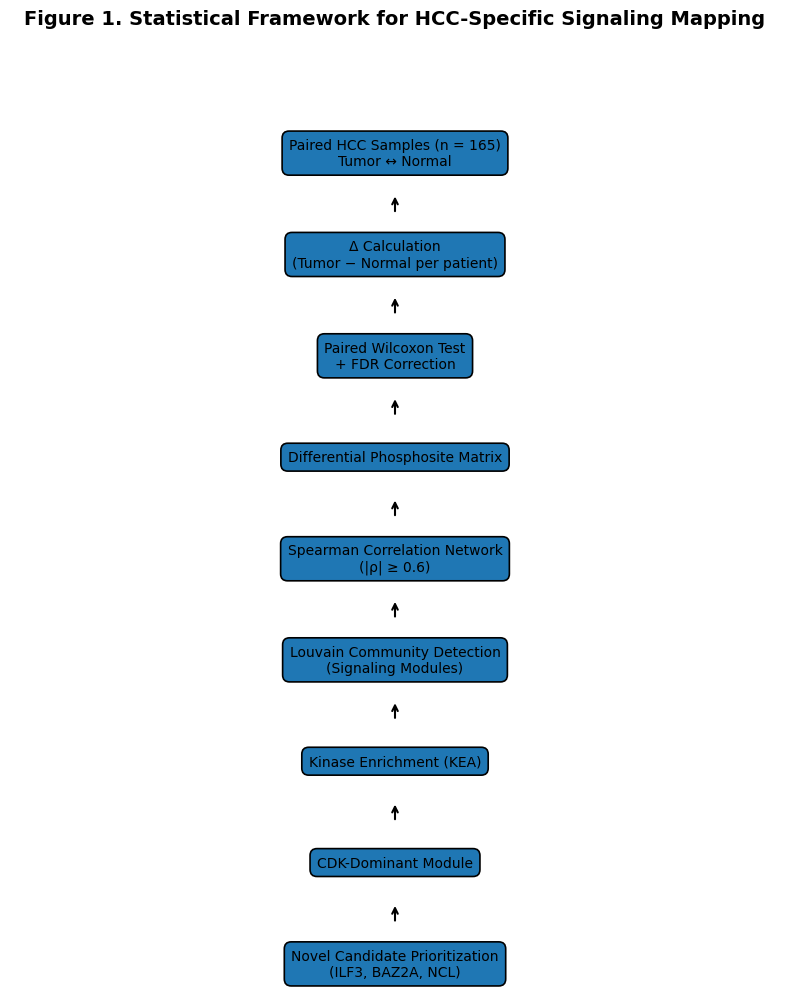

In [120]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis("off")

steps = [
    "Paired HCC Samples (n = 165)\nTumor ↔ Normal",
    "Δ Calculation\n(Tumor − Normal per patient)",
    "Paired Wilcoxon Test\n+ FDR Correction",
    "Differential Phosphosite Matrix",
    "Spearman Correlation Network\n(|ρ| ≥ 0.6)",
    "Louvain Community Detection\n(Signaling Modules)",
    "Kinase Enrichment (KEA)",
    "CDK-Dominant Module",
    "Novel Candidate Prioritization\n(ILF3, BAZ2A, NCL)"
]

y_positions = list(range(16, -1, -2))

for y, text in zip(y_positions, steps):
    ax.text(
        5, y, text,
        ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.5", linewidth=1.2)
    )

for i in range(len(y_positions)-1):
    ax.annotate(
        "",
        xy=(5, y_positions[i]-0.8),
        xytext=(5, y_positions[i+1]+0.8),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

ax.set_title("Figure 1. Statistical Framework for HCC-Specific Signaling Mapping",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Figure1_framework_clean.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "Figure1_framework_clean.pdf"), dpi=300)
#plt.close()

print("Improved Figure 1 saved.")


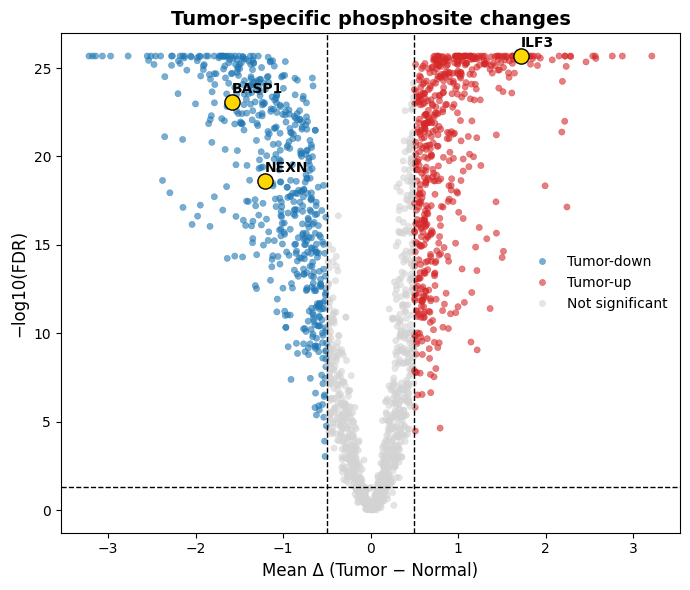

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# Thresholds
fdr_thr = 0.05
delta_thr = 0.5

summary["neglog10_fdr"] = -np.log10(summary["fdr"])

# Categorize
conditions = [
    (summary["fdr"] < fdr_thr) & (summary["mean_delta"] > delta_thr),
    (summary["fdr"] < fdr_thr) & (summary["mean_delta"] < -delta_thr)
]
choices = ["Tumor-up", "Tumor-down"]
summary["group"] = np.select(conditions, choices, default="Not significant")

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=summary,
    x="mean_delta",
    y="neglog10_fdr",
    hue="group",
    palette={
        "Tumor-up": "#d62728",
        "Tumor-down": "#1f77b4",
        "Not significant": "lightgrey"
    },
    alpha=0.6,
    edgecolor=None,
    s=20
)

# Threshold lines
plt.axhline(-np.log10(fdr_thr), linestyle="--", color="black", linewidth=1)
plt.axvline(delta_thr, linestyle="--", color="black", linewidth=1)
plt.axvline(-delta_thr, linestyle="--", color="black", linewidth=1)

# Highlight top 3 candidates
top3 = summary.sort_values("score", ascending=False).head(3)

for _, row in top3.iterrows():
    plt.scatter(row["mean_delta"], row["neglog10_fdr"],
                color="gold", edgecolor="black", s=120, zorder=5)
    plt.text(row["mean_delta"],
             row["neglog10_fdr"] + 0.5,
             row["symbol"],
             fontsize=10,
             weight="bold")

plt.xlabel("Mean Δ (Tumor − Normal)", fontsize=12)
plt.ylabel("−log10(FDR)", fontsize=12)
plt.title("Tumor-specific phosphosite changes", fontsize=14, weight="bold")
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("HCC_project/results/Figure2A_volcano_clean.pdf")
plt.show()
